### Toy example: Newsvendor problem

#### Imports

In [1]:
import numpy as np
from tqdm import tqdm
import time

from bayesian_dro.Bayesian_DRO_continuous import (
    main_Bayesian_DRO, data_generation, xi_generation, theta_generation, main_Bayesian_DRO_epsilon1
)
from mis_dro.dataset import data_generation_outliers
from mis_dro.npl import Npl

#### Sample observations from DGP

In [3]:
# set random seed
myseed = np.random.seed(0)


num_observations = 1000

# DGP is a truncated normal
# data = data_generation(num_observations)
# data.shape

### Alaternative function to sample observations with outliers

In [4]:
myseed = np.random.seed(0)

# DGP is a truncated normal with outliers
n_cont = 0.2
data = data_generation_outliers(num_observations, n_cont)
data.shape

(1000,)

Plot observations

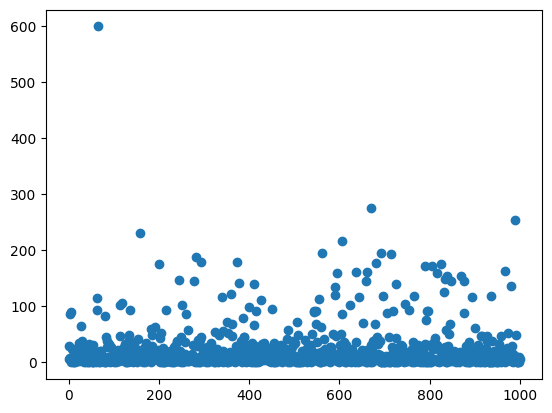

In [5]:
import matplotlib.pyplot as plt
plt.scatter(range(num_observations), data)

#### Generate NPL posterior samples

In [17]:
n = num_observations
B = 1000 # number of bootstrap iterations
p = 1 # numbers of unknown parameters

npl_toy = Npl(data.reshape((n,1)),B, p, loss_fn='wll')  # can change loss_fn to wll or mmd
t0 = time.time()
npl_toy.draw_samples()
t1 = time.time()
total = t1-t0
print(f'Total time: {total} seconds')
sample = npl_toy.sample

Total time: 1.1244490146636963 seconds


## Bayesian DRO with NPL Posterior

Sample $\theta$ from the NPL posterior, then apply Bayesian DRO algorithm.

In [18]:
EPSILON = 1.0   # fix epsilon for now
theta_npl = sample
xi = np.zeros([B, num_observations])
for i in range(B):
    xi[i] = xi_generation(theta_npl[i], num_observations)
#solution_BDRO_NPL = main_Bayesian_DRO(xi, EPSILON) # fixed epsilon
solution_epsilon_1_npl, epsilon_1_dro = main_Bayesian_DRO_epsilon1(data, theta_npl, xi)

/Users/cdellaporta/Desktop/mis-dro-code/bayesian_dro/Bayesian_DRO_continuous.py:210: RuntimeWarning: overflow encountered in exp
  np.mean(np.exp(cost(x, xi[theta_index, :]) / lam))
/Users/cdellaporta/Library/Python/3.9/lib/python/site-packages/scipy/optimize/_numdiff.py:576: RuntimeWarning: invalid value encountered in subtract
  df = fun(x) - f0


In [19]:
# solution_BDRO_NPL
solution_epsilon_1_npl

44.71999999999986

## Bayesian DRO

In [21]:
EPSILON = 1.0   # fix epsilon for now
theta = theta_generation(data, B)
xi = np.zeros([B, num_observations])
for i in range(B):
    xi[i] = xi_generation(theta[i], num_observations)
# solution_BDRO = main_Bayesian_DRO(xi, EPSILON)
solution_epsilon_1, epsilon_1_dro = main_Bayesian_DRO_epsilon1(data, theta, xi)

In [22]:
#solution_BDRO
solution_epsilon_1

45.30999999999974

Cost function

In [24]:
b = 4
h = 3
def cost(x, xi):
    return h * np.maximum(0, x - xi) + b * np.maximum(0, xi - x)

In [25]:
# Some new data to approximate true expected cost
myseed = np.random.seed(20)
#data_eval = data_generation_outliers(10000, 0)
data_eval = data_generation(10000)
# cost_BDRO_NPL = cost(solution_BDRO_NPL, data_eval)
# cost_BDRO = cost(solution_BDRO, data_eval)
cost_BDRO_NPL = cost(solution_epsilon_1_npl, data_eval)
cost_BDRO = cost(solution_epsilon_1, data_eval)
print(cost_BDRO_NPL.mean(), cost_BDRO.mean())
print(cost_BDRO_NPL.std(), cost_BDRO.std())

74.10667810128356 75.8766781012832
2.9983403258755073 2.9983403258755073


Perform experiment for K = 200 replications and calculate out-of-sample mean and variance 

In [96]:
myseed_eval = np.random.seed(20) # change for each j
test_num_obs = 10000 # number of test observations
K = 200 # number of experiment runs 
num_observations = 1000
B = 1000 # number of bootstrap iterations
p = 1 # numbers of unknown parameters
EPSILON = 1.0
cost_bayes = np.zeros((K,2))  # init costs for each run
cost_npl = np.zeros((K,2))

for j in tqdm(range(K)):
    myseed = np.random.seed(j) 
    data = data_generation(num_observations) # generate new observations
    data_eval = data_generation(test_num_obs) # test data ## when we use the outlier data gen. function remember to specify contamination level for test data 
    npl_toy = npl(data.reshape((n,1)),B, p, loss_fn='wll')  # can change loss_fn to wll or mmd
    npl_toy.draw_samples()
    npl_theta_sample = npl_toy.sample  # NPL posterior sample for theta
    bayes_theta_sample = theta_generation(data, B) # standard Bayesian posterior sample for theta
    xi_bayes = np.zeros([B, num_observations])  # init the xi's 
    xi_NPL = np.zeros([B, num_observations])
    for i in range(B):
        xi_bayes[i] = xi_generation(bayes_theta_sample[i], num_observations)
        xi_NPL[i] = xi_generation(npl_theta_sample[i], num_observations)
    solution_BDRO = main_Bayesian_DRO(xi_bayes, EPSILON)
    solution_BDRO_NPL = main_Bayesian_DRO(xi_NPL, EPSILON)
    cost_bayes_current = cost(solution_BDRO, data_eval)
    cost_npl_current = cost(solution_BDRO_NPL, data_eval)
    cost_bayes[j,:] = cost_bayes_current.mean(), cost_bayes_current.std()**2
    cost_npl[j,:] = cost_npl_current.mean(), cost_npl_current.std()**2
    
# Calculate out-of-sample mean and variance
mean_bayes = cost_bayes[:,0].mean()
var_bayes = cost_bayes[:,1].mean() + (1/(K-1))*np.sum((cost_bayes[:,0]-mean_bayes)**2)
mean_npl = cost_npl[:,0].mean()
var_npl = cost_npl[:,1].mean() + (1/(K-1))*np.sum((cost_npl[:,0]-mean_npl)**2)
print(f'BDRO has out-of-sample mean: {mean_bayes} and out-of-sample variance: {var_bayes}')
print(f'BDRO-NPL has out-of-sample mean: {mean_npl} and out-of-sample variance: {var_npl}')


 18%|█▊        | 36/200 [19:53<1:30:00, 32.93s/it]/Users/cdellaporta/Library/Python/3.9/lib/python/site-packages/numpy/core/_methods.py:118: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
100%|██████████| 200/200 [1:50:00<00:00, 33.00s/it]

BDRO has out-of-sample mean: 46.83532301023784 and out-of-sample variance: 148.19237060827953
BDRO-NPL has out-of-sample mean: 46.892389236439215 and out-of-sample variance: 146.9086461303539
